In [ ]:
!pip install -U ipywidgets tqdm

: 

In [ ]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import math
from tqdm import tqdm

# Initialize Roboflow client
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="R1zODk2Ja9JHBabfRASg"
)

# Run workflow on image
result = client.run_workflow(
    workspace_name="fabiki4429-acoxs-com",
    workflow_id="general-segmentation-api-2",
    images={"image": "image.png"},
    parameters={"classes": "ear"},
    use_cache=True
)

# Extract ear points
prediction = result[0]['predictions']['predictions'][0]
points = np.array(
    [[p["x"], p["y"]] for p in prediction["points"]],
    dtype=np.int32
)

HTTPCallErrorError: HTTPCallErrorError(description='400 Client Error: Bad Request for url: https://serverless.roboflow.com/fabiki4429-acoxs-com/workflows/general-segmentation-api-2', api_message='Failed to assemble `image`. Could not successfully use any deserializer for declared kinds. Details: 
Kind: `image` - Error: Detected runtime parameter `image` defined as `WorkflowImage` that is invalid. Failed on input validation. Details: NumPy image type is not supported in this configuration of `inference`.. More details: None',status_code=400)

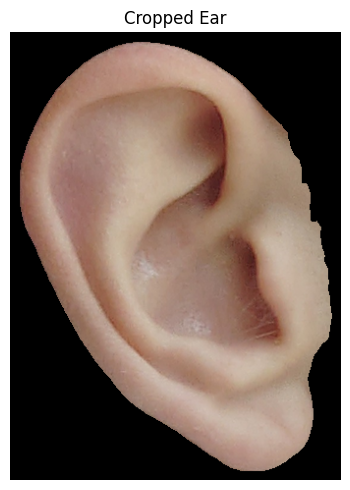

True

In [ ]:
# Create mask and extract ear (crop view)
image = cv2.imread("right-profile.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = np.zeros(image.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [points], 255)

ear_cropped = cv2.bitwise_and(image, image, mask=mask)

# Find bounding box and crop
xs, ys = points[:, 0], points[:, 1]
min_x, max_x = xs.min(), xs.max()
min_y, max_y = ys.min(), ys.max()

# Crop with small padding
pad = 10
crop_box = (
    max(0, min_x - pad),
    max(0, min_y - pad),
    min(image.shape[1], max_x + pad),
    min(image.shape[0], max_y + pad)
)

ear_only = ear_cropped[crop_box[1]:crop_box[3], crop_box[0]:crop_box[2]]

plt.figure(figsize=(4, 5))
plt.imshow(ear_only)
plt.axis("off")
plt.title("Cropped Ear")
plt.tight_layout()
plt.show()

# Save cropped ear
ear_rgb = cv2.cvtColor(ear_only, cv2.COLOR_RGB2BGR)
cv2.imwrite('ear_cropped.jpg', ear_rgb)

Measurements: {'output_path': 'ear_with_measurements.png', 'ear_height_px': 436, 'ear_width_top_px': 270}


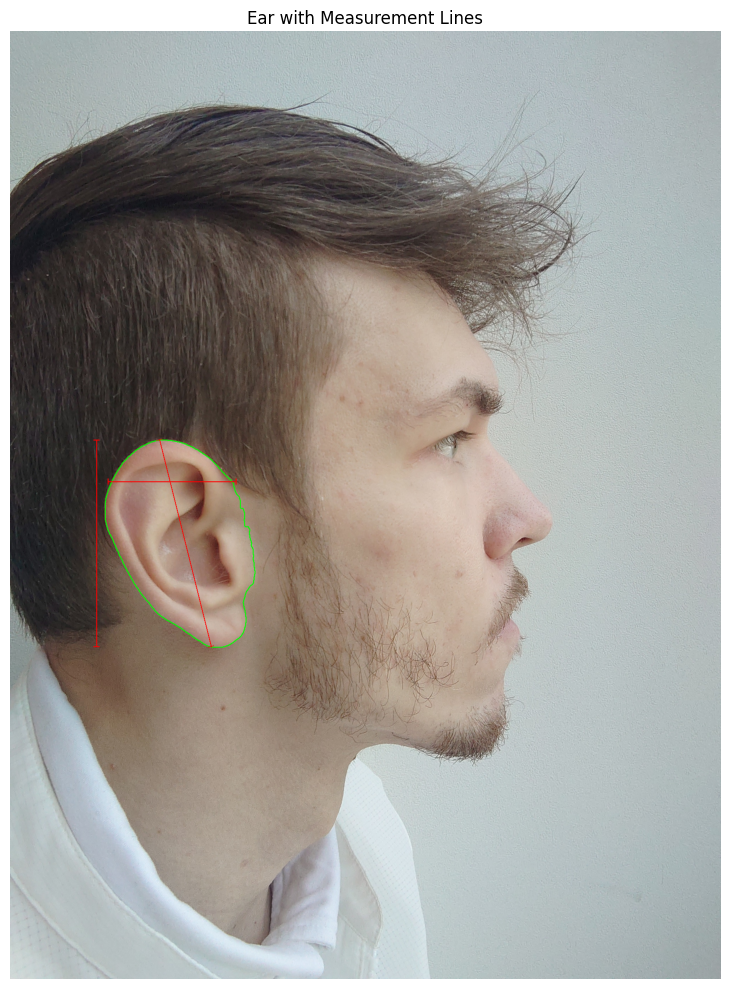

In [3]:
def _draw_capped_line(draw, p1, p2, color, width, cap_len):
    """Draw line with perpendicular end-cap ticks (caliper style)"""
    draw.line([p1, p2], fill=color, width=width)

    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    length = math.hypot(dx, dy)
    if length == 0:
        return
    ux, uy = dx / length, dy / length
    px, py = -uy, ux
    half = cap_len / 2
    for (cx, cy) in (p1, p2):
        a = (cx - px * half, cy - py * half)
        b = (cx + px * half, cy + py * half)
        draw.line([a, b], fill=color, width=width)


def draw_ear_on_fullimage(
    image_path,
    points,
    output_path="ear_with_lines.png",
    line_color=(255, 0, 0),
    outline_color=(0, 255, 0),
    line_width=2,
    cap_len=12,
):
    """
    Draw ear outline and measurement lines on full image.
    Lines: vertical (height), horizontal (top width), diagonal (true axis)
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    ear_w_px, ear_h_px = max_x - min_x, max_y - min_y

    draw = ImageDraw.Draw(img)

    # Draw ear outline
    pts_tuples = [tuple(p) for p in points]
    draw.line(pts_tuples + [pts_tuples[0]], fill=outline_color, width=2, joint="curve")

    # Vertical caliper (left of ear)
    vx = min_x - 18
    _draw_capped_line(draw, (vx, min_y), (vx, max_y), line_color, line_width, cap_len)

    # Horizontal caliper (top of ear)
    hy = min_y + (max_y - min_y) * 0.20
    band = [p for p in points if abs(p[1] - hy) < (max_y - min_y) * 0.05]
    if band:
        hx_left = min(p[0] for p in band)
        hx_right = max(p[0] for p in band)
    else:
        hx_left, hx_right = min_x, max_x
    _draw_capped_line(draw, (hx_left, hy), (hx_right, hy), line_color, line_width, cap_len)

    # Diagonal caliper (top point -> bottom point)
    top_pt = min(points, key=lambda p: p[1])
    bottom_pt = max(points, key=lambda p: p[1])
    _draw_capped_line(draw, tuple(top_pt), tuple(bottom_pt), line_color, line_width, cap_len)

    img.save(output_path)
    
    return {
        "output_path": output_path,
        "ear_height_px": ear_h_px,
        "ear_width_top_px": hx_right - hx_left,
    }


# Convert numpy points to regular list for Image operations
points_list = points.tolist()

# Draw measurements on full image
measurements = draw_ear_on_fullimage(
    'right-profile.png',
    points_list,
    'ear_with_measurements.png',
    line_color=(255, 0, 0),
    outline_color=(0, 255, 0)
)

print("Measurements:", measurements)

# Display result
result_img = Image.open('ear_with_measurements.png')
plt.figure(figsize=(8, 10))
plt.imshow(result_img)
plt.axis("off")
plt.title("Ear with Measurement Lines")
plt.tight_layout()
plt.show()